<a href="https://colab.research.google.com/github/Paari18/Customer-Segmentation-using-RFM-Analysis/blob/main/Customer_Segmentation_using_RFM_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import gdown
import pandas as pd

file_id = "1FO-0o23zcqOaY8Ajbvy9TJM4cg0-IItX"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset.csv", quiet=False)

df = pd.read_csv("dataset.csv")
print(df.head())

Downloading...
From: https://drive.google.com/uc?id=1FO-0o23zcqOaY8Ajbvy9TJM4cg0-IItX
To: /content/dataset.csv
100%|██████████| 48.6M/48.6M [00:00<00:00, 73.0MB/s]


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [ ]:
df.head()
df.info()
df.shape
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

RFM Analysis

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:
snapshot_date = df["InvoiceDate"].max()

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,2,0.00
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [ ]:
rfm["R"] = pd.qcut(
    rfm["Recency"],
    5,
    labels=[5,4,3,2,1]
)

rfm["F"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5]
)

rfm["M"] = pd.qcut(
    rfm["Monetary"],
    5,
    labels=[1,2,3,4,5]
)

rfm.head()

,Recency,Frequency,Monetary,R,F,M
CustomerID,,,,,,
12346.0,325,2,0.00,1,2,1
12347.0,1,7,4310.00,5,4,5
12348.0,74,4,1797.24,2,3,4
12349.0,18,1,1757.55,4,1,4
12350.0,309,1,334.40,1,1,2


In [ ]:
rfm["RFM_Score"] = (
    rfm["R"].astype(str)
    + rfm["F"].astype(str)
    + rfm["M"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score
CustomerID,,,,,,,
12346.0,325,2,0.00,1,2,1,121
12347.0,1,7,4310.00,5,4,5,545
12348.0,74,4,1797.24,2,3,4,234
12349.0,18,1,1757.55,4,1,4,414
12350.0,309,1,334.40,1,1,2,112


In [ ]:
def segment_customer(row):

    if row["R"] >= 4 and row["F"] >= 4:
        return "Champions"

    elif row["R"] >= 3 and row["F"] >= 3:
        return "Loyal Customers"

    elif row["R"] >= 4:
        return "Potential Loyalists"

    elif row["R"] <= 2 and row["F"] >= 3:
        return "At Risk"

    else:
        return "Lost Customers"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [ ]:
rfm["Segment"].value_counts()

,count
Segment,
Lost Customers,1419
Champions,1144
Loyal Customers,802
At Risk,677
Potential Loyalists,330


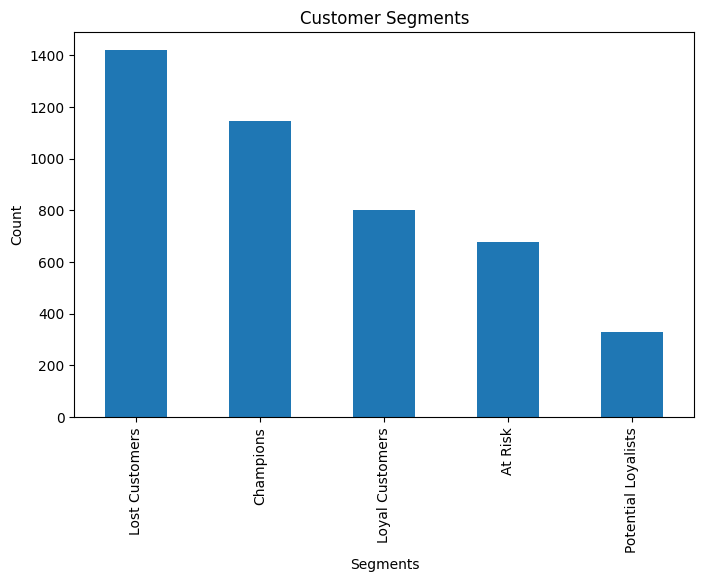

In [ ]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Segments")
plt.xlabel("Segments")
plt.ylabel("Count")
plt.show()

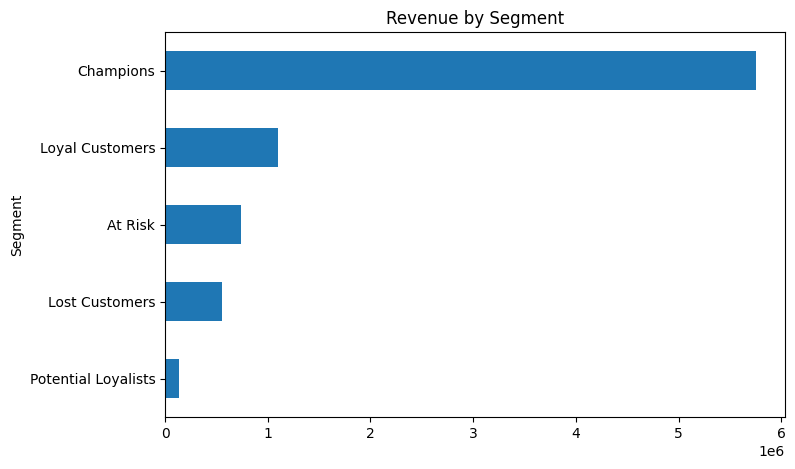

In [ ]:
rfm.groupby("Segment")["Monetary"].sum().sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Revenue by Segment")
plt.show()

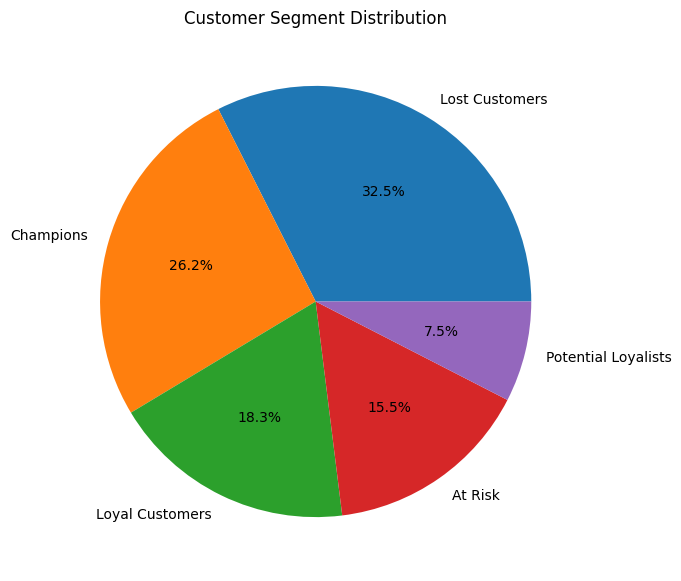

In [ ]:
rfm["Segment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.ylabel("")
plt.title("Customer Segment Distribution")
plt.show()

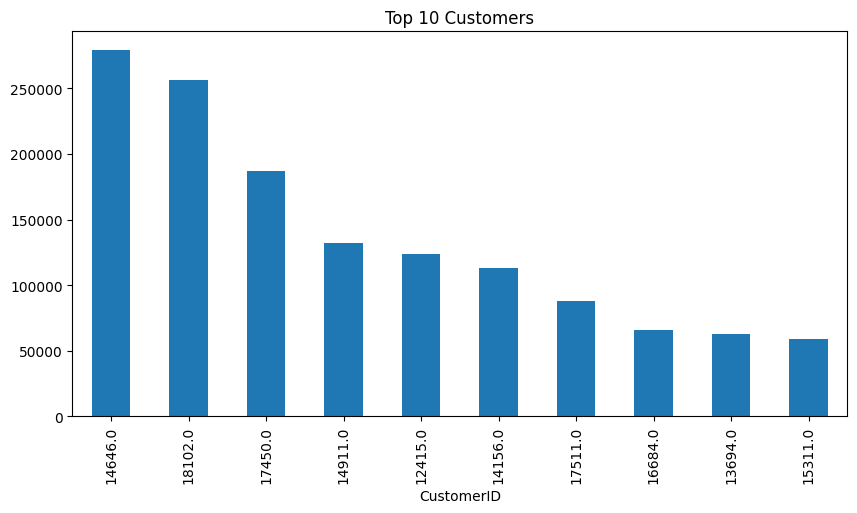

In [ ]:
top_customers = rfm.sort_values(
    "Monetary",
    ascending=False
).head(10)

top_customers["Monetary"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Customers")
plt.show()

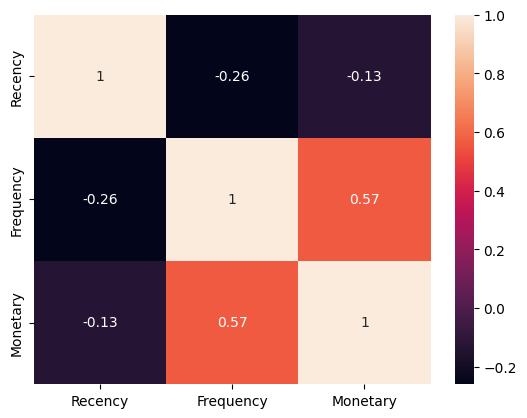

In [ ]:
import seaborn as sns

sns.heatmap(
    rfm[["Recency","Frequency","Monetary"]].corr(),
    annot=True
)

plt.show()

In [ ]:
rfm.to_csv("RFM_Analysis_Output.csv")